In [33]:
import pandas as pd

In [34]:
def load_fbref_csv(filepath):
    df = pd.read_csv(filepath, header = [0,1])
    df.columns = [
        '_'.join(col).strip()
        if 'Unnamed' not in col[0]
        else col[1].strip()
        for col in df.columns
    ]
    df = df.drop(index=0).reset_index(drop=True)
    return df

In [35]:
df_standard = load_fbref_csv("../data/raw/standard.csv")

df_standard = df_standard.rename(columns={
    'Unnamed: 0_level_1': 'league',
    'Unnamed: 1_level_1': 'season',
    'Unnamed: 2_level_1': 'team',
    'Unnamed: 3_level_1': 'player',
    'nation_Unnamed: 4_level_1': 'nation',
    'pos_Unnamed: 5_level_1': 'pos',
    'age_Unnamed: 6_level_1': 'age',
    'born_Unnamed: 7_level_1': 'born',
    'Playing Time_MP': 'matches',
    'Playing Time_Starts': 'starts',
    'Playing Time_Min': 'minutes',
    'Playing Time_90s': '90s',
    'Performance_Gls': 'goals',
    'Performance_Ast': 'assists',
    'Performance_G+A': 'goal_contributions',
    'Performance_G-PK': 'goals_excl_pk',
    'Performance_PK': 'pk_scored',
    'Performance_PKatt': 'pk_attempted',
    'Performance_CrdY': 'yellow_cards',
    'Performance_CrdR': 'red_cards',
    'Per 90 Minutes_Gls': 'goals_p90',
    'Per 90 Minutes_Ast': 'assists_p90',
    'Per 90 Minutes_G+A': 'goal_contributions_p90',
    'Per 90 Minutes_G-PK': 'goals_excl_pk_p90',
    'Per 90 Minutes_G+A-PK': 'goal_contributions_excl_pk_p90'
})
print(df_standard.columns)
#print(df_standard.shape)
print(df_standard.head())

Index(['league', 'season', 'team', 'player', 'nation', 'pos', 'age', 'born',
       'matches', 'starts', 'minutes', '90s', 'goals', 'assists',
       'goal_contributions', 'goals_excl_pk', 'pk_scored', 'pk_attempted',
       'yellow_cards', 'red_cards', 'goals_p90', 'assists_p90',
       'goal_contributions_p90', 'goals_excl_pk_p90',
       'goal_contributions_excl_pk_p90'],
      dtype='str')
               league season     team                  player nation    pos  \
0  ENG-Premier League   1920  Arsenal  Ainsley Maitland-Niles    ENG     DF   
1  ENG-Premier League   1920  Arsenal     Alexandre Lacazette    FRA     FW   
2  ENG-Premier League   1920  Arsenal              Bernd Leno    GER     GK   
3  ENG-Premier League   1920  Arsenal             Bukayo Saka    ENG  MF,DF   
4  ENG-Premier League   1920  Arsenal          Calum Chambers    ENG     DF   

    age    born  matches  starts  ...  goals_excl_pk  pk_scored  pk_attempted  \
0  21.0  1997.0     20.0    15.0  ...          

In [36]:
df_shooting = load_fbref_csv("../data/raw/shooting.csv")

df_shooting = df_shooting.rename(columns={
    'Unnamed: 0_level_1': 'league',
    'Unnamed: 1_level_1': 'season',
    'Unnamed: 2_level_1': 'team',
    'Unnamed: 3_level_1': 'player',
    'nation_Unnamed: 4_level_1': 'nation',
    'pos_Unnamed: 5_level_1': 'pos',
    'age_Unnamed: 6_level_1': 'age',
    'born_Unnamed: 7_level_1': 'born',
    '90s_Unnamed: 8_level_1': '90s',
    'Standard_Gls': 'goals',
    'Standard_Sh': 'shots',
    'Standard_SoT': 'shots_on_target',
    'Standard_SoT%': 'shot_accuracy',
    'Standard_Sh/90': 'shots_p90',
    'Standard_SoT/90': 'shots_on_target_p90',
    'Standard_G/Sh': 'goals_per_shot',
    'Standard_G/SoT': 'goals_per_shot_on_target',
    'Standard_PK': 'pk_scored',
    'Standard_PKatt': 'pk_attempted'
})

print(df_shooting.columns)
#print(df_shooting.shape)
print(df_shooting.head())

Index(['league', 'season', 'team', 'player', 'nation', 'pos', 'age', 'born',
       '90s', 'goals', 'shots', 'shots_on_target', 'shot_accuracy',
       'shots_p90', 'shots_on_target_p90', 'goals_per_shot',
       'goals_per_shot_on_target', 'pk_scored', 'pk_attempted'],
      dtype='str')
               league season     team                  player nation    pos  \
0  ENG-Premier League   1920  Arsenal  Ainsley Maitland-Niles    ENG     DF   
1  ENG-Premier League   1920  Arsenal     Alexandre Lacazette    FRA     FW   
2  ENG-Premier League   1920  Arsenal              Bernd Leno    GER     GK   
3  ENG-Premier League   1920  Arsenal             Bukayo Saka    ENG  MF,DF   
4  ENG-Premier League   1920  Arsenal          Calum Chambers    ENG     DF   

    age    born   90s  goals  shots  shots_on_target  shot_accuracy  \
0  21.0  1997.0  15.4    0.0    4.0              1.0           25.0   
1  28.0  1991.0  20.8   10.0   53.0             26.0           49.1   
2  27.0  1992.0  29.4 

In [37]:
df_standard["league"] = df_standard["league"].replace("", pd.NA).fillna("GER-Bundesliga")
df_shooting["league"] = df_shooting["league"].replace("", pd.NA).fillna("GER-Bundesliga")

In [38]:
# Merging the data

shooting_cols = ['league', 'season', 'team', 'player', 
                 'shots', 'shots_on_target', 'shot_accuracy',
                 'shots_p90', 'shots_on_target_p90', 
                 'goals_per_shot', 'goals_per_shot_on_target']

df_merged = pd.merge(
    df_standard,
    df_shooting[shooting_cols],
    on=['league', 'season', 'team', 'player'],
    how='left'
)

print(df_merged.shape)
print(df_merged.columns)
print(df_merged.dtypes)

(17071, 32)
Index(['league', 'season', 'team', 'player', 'nation', 'pos', 'age', 'born',
       'matches', 'starts', 'minutes', '90s', 'goals', 'assists',
       'goal_contributions', 'goals_excl_pk', 'pk_scored', 'pk_attempted',
       'yellow_cards', 'red_cards', 'goals_p90', 'assists_p90',
       'goal_contributions_p90', 'goals_excl_pk_p90',
       'goal_contributions_excl_pk_p90', 'shots', 'shots_on_target',
       'shot_accuracy', 'shots_p90', 'shots_on_target_p90', 'goals_per_shot',
       'goals_per_shot_on_target'],
      dtype='str')
league                                str
season                                str
team                                  str
player                                str
nation                                str
pos                                   str
age                               float64
born                              float64
matches                           float64
starts                            float64
minutes                       

In [39]:
# Processing the merged dataset

# Now let us remove players with playtime below 900 minutes ~~ 10 full 90 minute games (standard threshold used in football analytics)
df_merged = df_merged[df_merged['minutes'] >= 900]
print(df_merged.shape)

# Dropping redundant columns - we already have age and minutes (90s is minutes/90) so we can safely exclude born and 90s
df_merged = df_merged.drop(columns=['born', '90s'])
print("Final Shape:", df_merged.shape)

# Saving the merged and cleaned data to a new csv file for further processing
df_merged.to_csv("../data/processed/merged.csv", index=False)
print("Saved!")


(9626, 32)
Final Shape: (9626, 30)
Saved!


In [40]:
print(df_merged['pos'].isna().sum()) # Checking for NaN values
print(df_merged['pos'].unique()) # Checking for all the different unique positions under the pos column

0
<StringArray>
['DF', 'FW', 'GK', 'MF,DF', 'MF', 'DF,MF', 'MF,FW', 'FW,MF', 'DF,FW']
Length: 9, dtype: str


In [41]:
# Creating a separate dataframe to store the attackers (people who contribute to goals) only
df_attackers = df_merged[df_merged['pos'].str.contains('FW') | df_merged['pos'].str.contains('MF')].copy()
print(df_attackers.shape)
df_attackers['pos'].unique()

(6181, 30)


<StringArray>
['FW', 'MF,DF', 'MF', 'DF,MF', 'MF,FW', 'FW,MF', 'DF,FW']
Length: 7, dtype: str

## Data Overview

Basic shape/dtype/missingness check on the cleaned, merged dataset before digging into
distributions.

In [42]:
print(f"Rows: {df_merged.shape[0]:,}  |  Columns: {df_merged.shape[1]}")
df_merged.dtypes


Rows: 9,626  |  Columns: 30


league                                str
season                                str
team                                  str
player                                str
nation                                str
pos                                   str
age                               float64
matches                           float64
starts                            float64
minutes                           float64
goals                             float64
assists                           float64
goal_contributions                float64
goals_excl_pk                     float64
pk_scored                         float64
pk_attempted                      float64
yellow_cards                      float64
red_cards                         float64
goals_p90                         float64
assists_p90                       float64
goal_contributions_p90            float64
goals_excl_pk_p90                 float64
goal_contributions_excl_pk_p90    float64
shots                             

In [43]:
# Several numeric columns come in as object/string dtype straight out of FBref's CSV export.
# Coerce everything that should be numeric.
id_cols = ['league', 'season', 'team', 'player', 'nation', 'pos']
numeric_cols = [c for c in df_merged.columns if c not in id_cols]

for c in numeric_cols:
    df_merged[c] = pd.to_numeric(df_merged[c], errors='coerce')

df_merged[numeric_cols].dtypes.value_counts()


float64    24
Name: count, dtype: int64

In [44]:
missing = (df_merged.isna().mean() * 100).sort_values(ascending=False)
missing[missing > 0].to_frame('pct_missing')


,pct_missing
goals_per_shot_on_target,13.681695
shot_accuracy,8.092666
goals_per_shot,8.092666
shots,0.872637
shots_p90,0.872637
shots_on_target,0.872637
shots_on_target_p90,0.872637
nation,0.010389


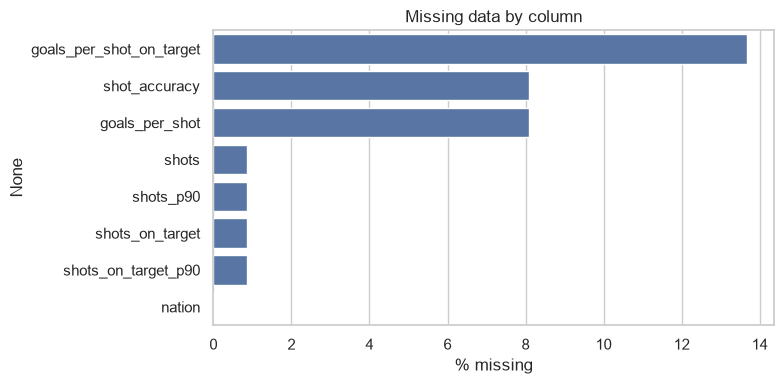

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(figsize=(8, 4))
missing_nonzero = missing[missing > 0]
if len(missing_nonzero):
    sns.barplot(x=missing_nonzero.values, y=missing_nonzero.index, ax=ax, color='#4C72B0')
    ax.set_xlabel('% missing')
    ax.set_title('Missing data by column')
plt.tight_layout()
plt.show()


In [46]:
# League / season coverage check
pd.crosstab(df_merged['season'], df_merged['league'])


league,ENG-Premier League,ESP-La Liga,FRA-Ligue 1,GER-Bundesliga,ITA-Serie A
season,,,,,
1920,328,330,279,282,334
2021,327,339,337,285,341
2122,343,344,339,277,334
2223,331,354,330,279,335
2324,339,340,291,296,342
2425,322,338,289,280,341


## Univariate EDA

Distributions of the target (`goals_excl_pk_p90`) and the key proxy features.

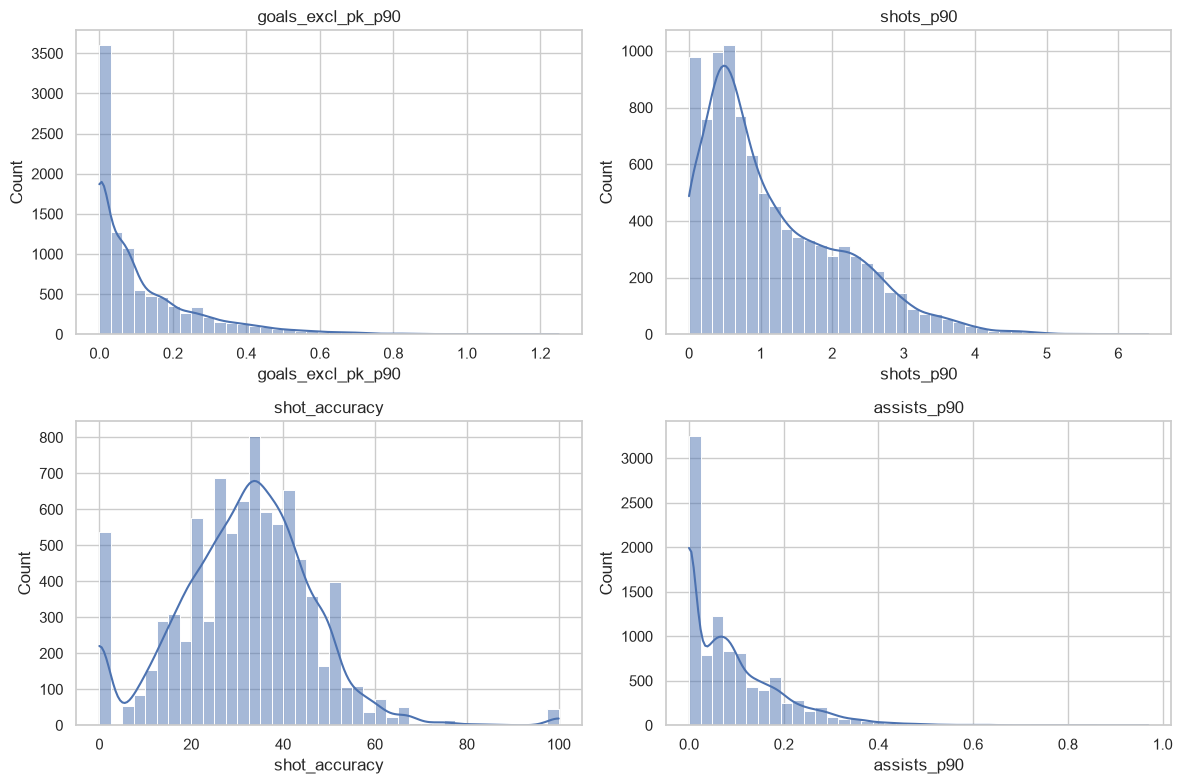

In [47]:
feats = ['goals_excl_pk_p90', 'shots_p90', 'shot_accuracy', 'assists_p90']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flat, feats):
    sns.histplot(df_merged[feat].dropna(), bins=40, kde=True, ax=ax, color='#4C72B0')
    ax.set_title(feat)
plt.tight_layout()
plt.show()


In [48]:
df_merged[feats].describe().T


,count,mean,std,min,25%,50%,75%,max
goals_excl_pk_p90,9626.0,0.115939,0.150806,0.0,0.00,0.06,0.17,1.25
shots_p90,9542.0,1.158775,0.958876,0.0,0.43,0.86,1.76,6.42
shot_accuracy,8847.0,31.539889,15.082590,0.0,22.20,32.80,40.60,100.00
assists_p90,9626.0,0.089596,0.101527,0.0,0.00,0.06,0.14,0.97


In [49]:
df_merged[feats].skew().sort_values(ascending=False).to_frame('skewness')


,skewness
goals_excl_pk_p90,2.008215
assists_p90,1.630651
shots_p90,1.029206
shot_accuracy,0.262446


## Bivariate & Correlation EDA

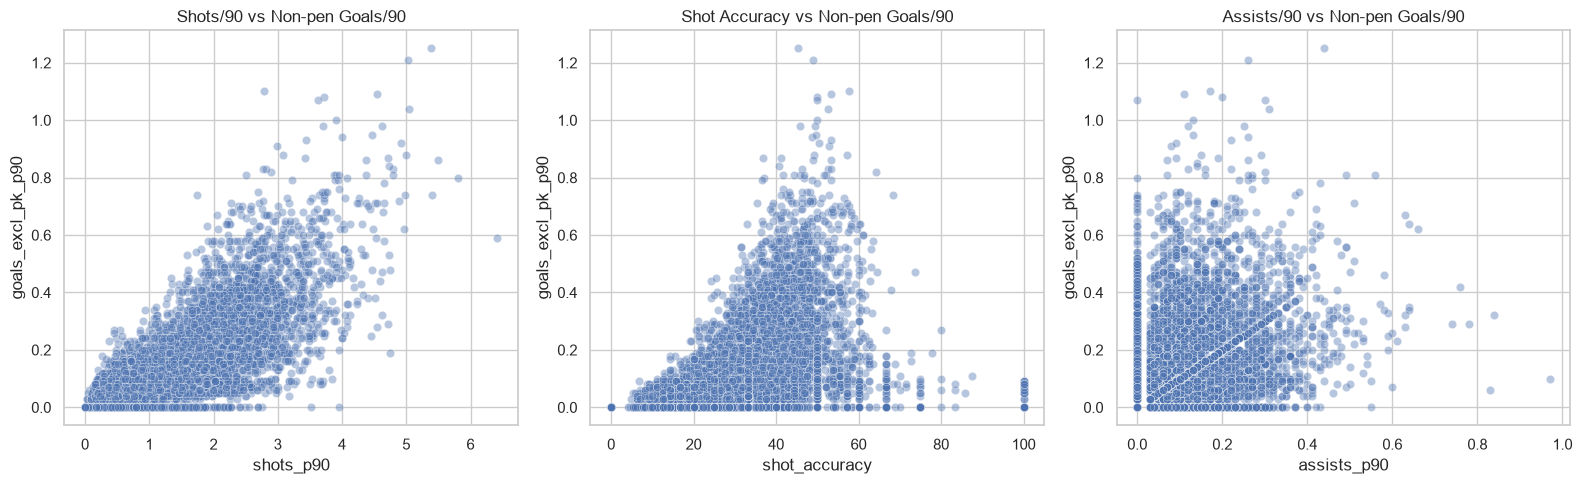

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.scatterplot(data=df_merged, x='shots_p90', y='goals_excl_pk_p90', alpha=0.4, ax=axes[0])
axes[0].set_title('Shots/90 vs Non-pen Goals/90')

sns.scatterplot(data=df_merged, x='shot_accuracy', y='goals_excl_pk_p90', alpha=0.4, ax=axes[1])
axes[1].set_title('Shot Accuracy vs Non-pen Goals/90')

sns.scatterplot(data=df_merged, x='assists_p90', y='goals_excl_pk_p90', alpha=0.4, ax=axes[2])
axes[2].set_title('Assists/90 vs Non-pen Goals/90')

plt.tight_layout()
plt.show()


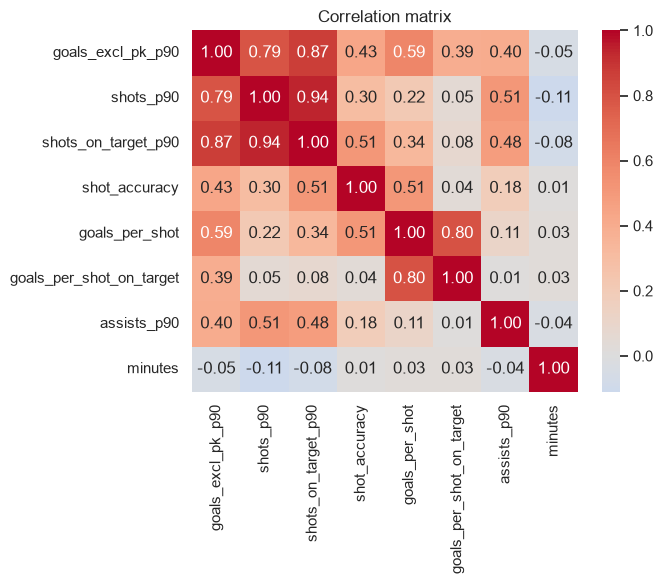

In [51]:
corr_cols = ['goals_excl_pk_p90', 'shots_p90', 'shots_on_target_p90', 'shot_accuracy',
             'goals_per_shot', 'goals_per_shot_on_target', 'assists_p90', 'minutes']
corr = df_merged[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation matrix')
plt.tight_layout()
plt.show()


## League-Level Comparison

Checks whether the target differs meaningfully by league — motivates adding a
league-quality adjustment before modelling (per the project plan).

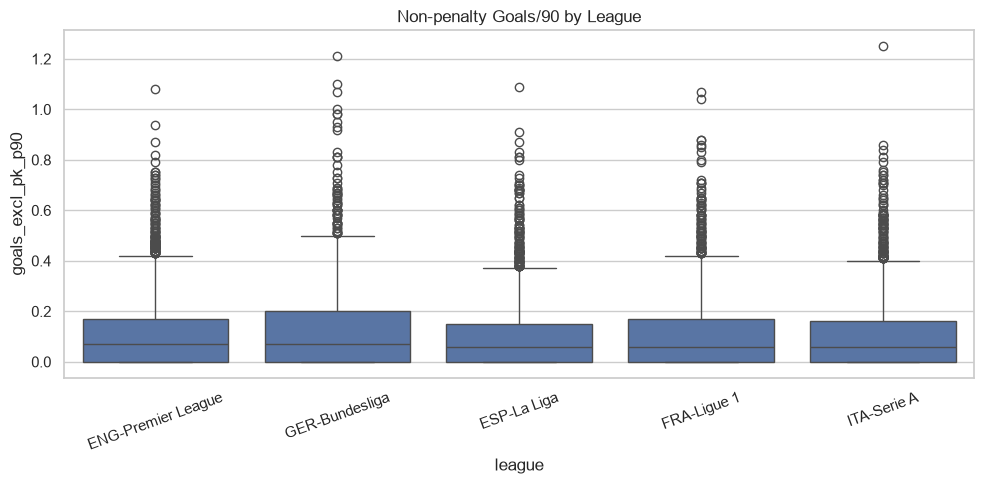

In [52]:
fig, ax = plt.subplots(figsize=(10, 5))
order = df_merged.groupby('league')['goals_excl_pk_p90'].median().sort_values(ascending=False).index
sns.boxplot(data=df_merged, x='league', y='goals_excl_pk_p90', order=order, ax=ax)
ax.set_title('Non-penalty Goals/90 by League')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


In [53]:
df_merged.groupby('league')[['goals_excl_pk_p90', 'shots_p90', 'shot_accuracy']].median() \
    .sort_values('goals_excl_pk_p90', ascending=False)


,goals_excl_pk_p90,shots_p90,shot_accuracy
league,,,
ENG-Premier League,0.07,0.88,33.3
GER-Bundesliga,0.07,0.92,33.3
ESP-La Liga,0.06,0.81,32.2
FRA-Ligue 1,0.06,0.83,33.3
ITA-Serie A,0.06,0.87,31.3


## Position-Level Comparison

Uses `df_attackers` (FW/MF) vs the full player pool to sanity-check that attacking
output is concentrated where you'd expect.

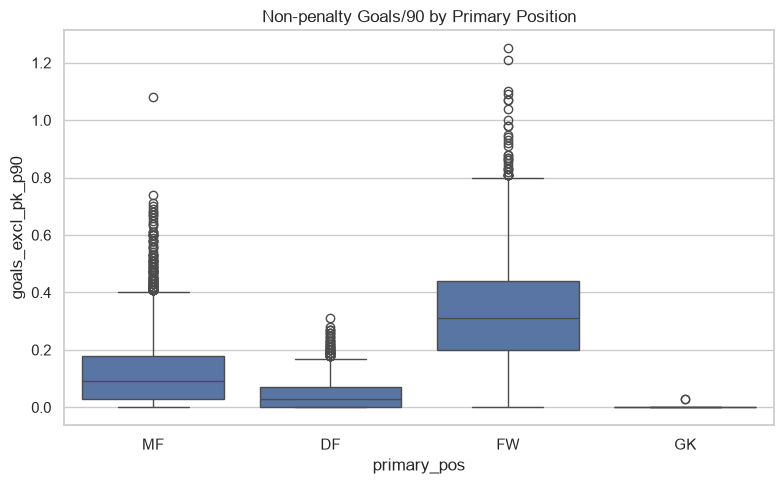

In [54]:
df_merged['primary_pos'] = df_merged['pos'].str.split(',').str[0]

fig, ax = plt.subplots(figsize=(8, 5))
pos_order = df_merged['primary_pos'].value_counts().index
sns.boxplot(data=df_merged, x='primary_pos', y='goals_excl_pk_p90', order=pos_order, ax=ax)
ax.set_title('Non-penalty Goals/90 by Primary Position')
plt.tight_layout()
plt.show()


## Season-Over-Season Trends

Relevant for the season-ahead forecasting stage of the project — how stable are
league-level scoring rates, and how much year-over-year signal exists at the
player level?

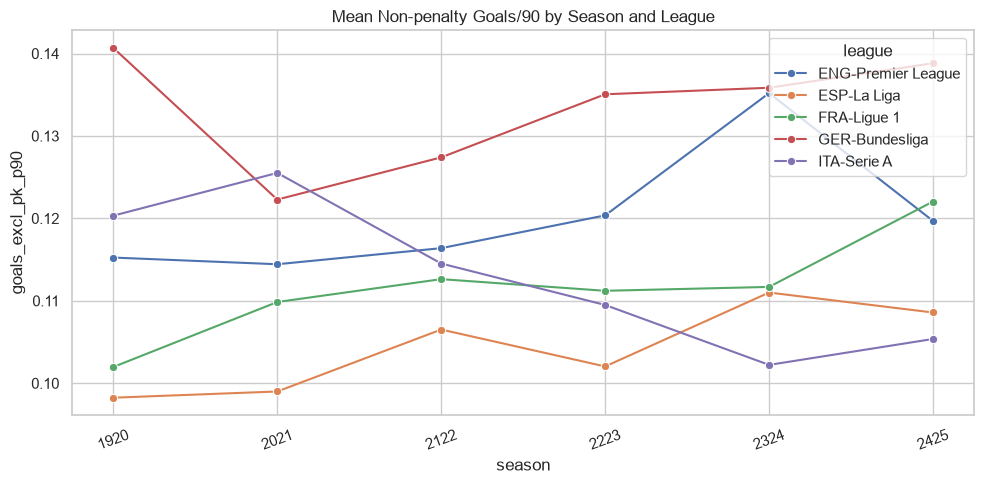

In [55]:
season_trend = df_merged.groupby(['season', 'league'])['goals_excl_pk_p90'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=season_trend, x='season', y='goals_excl_pk_p90', hue='league', marker='o', ax=ax)
ax.set_title('Mean Non-penalty Goals/90 by Season and League')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


Player-seasons with a same-team prior-season match: 4,552
Year-over-year correlation: 0.738


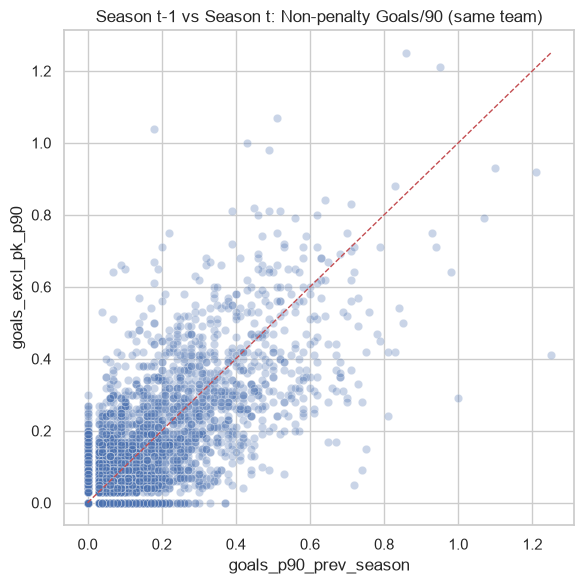

In [56]:
df_sorted = df_merged.sort_values(['player', 'team', 'season'])
df_sorted['goals_p90_prev_season'] = df_sorted.groupby(['player', 'team'])['goals_excl_pk_p90'].shift(1)

yoy = df_sorted.dropna(subset=['goals_p90_prev_season'])
print(f"Player-seasons with a same-team prior-season match: {len(yoy):,}")
print('Year-over-year correlation:', round(yoy['goals_p90_prev_season'].corr(yoy['goals_excl_pk_p90']), 3))

fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(data=yoy, x='goals_p90_prev_season', y='goals_excl_pk_p90', alpha=0.3, ax=ax)
lims = [0, max(yoy['goals_p90_prev_season'].max(), yoy['goals_excl_pk_p90'].max())]
ax.plot(lims, lims, 'r--', linewidth=1)
ax.set_title('Season t-1 vs Season t: Non-penalty Goals/90 (same team)')
plt.tight_layout()
plt.show()


## Outlier Scan

IQR-based flag on the target — not to remove outliers, just to eyeball who they are
(elite scorers vs. potential data issues).

In [57]:
def iqr_outliers(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return (series < lower) | (series > upper)

outlier_mask = iqr_outliers(df_merged['goals_excl_pk_p90'])
print(f"Outliers in goals_excl_pk_p90: {outlier_mask.sum()} of {len(df_merged)} ({outlier_mask.mean():.1%})")

df_merged.loc[outlier_mask, ['player', 'team', 'league', 'season', 'minutes', 'goals_excl_pk_p90']] \
    .sort_values('goals_excl_pk_p90', ascending=False).head(15)


Outliers in goals_excl_pk_p90: 496 of 9626 (5.2%)


,player,team,league,season,minutes,goals_excl_pk_p90
10941,Luis Muriel,Atalanta,ITA-Serie A,2021,1436.0,1.25
14604,Robert Lewandowski,Bayern Munich,GER-Bundesliga,2021,2458.0,1.21
14092,Erling Haaland,Dortmund,GER-Bundesliga,1920,1063.0,1.10
6358,Alexander Sørloth,Atlético Madrid,ESP-La Liga,2425,1566.0,1.09
955,Gareth Bale,Tottenham Hotspur,ENG-Premier League,2021,920.0,1.08
7284,Kylian Mbappé,Paris Saint-Germain,FRA-Ligue 1,1920,1513.0,1.07
16877,Patrik Schick,Leverkusen,GER-Bundesliga,2425,1684.0,1.07
10161,Ousmane Dembélé,Paris Saint-Germain,FRA-Ligue 1,2425,1730.0,1.04
15401,Patrik Schick,Leverkusen,GER-Bundesliga,2122,2076.0,1.00
16488,Serhou Guirassy,Stuttgart,GER-Bundesliga,2324,2208.0,0.98


## Save Attackers Subset

Persist `df_attackers` alongside the already-saved `merged.csv`, since it's the
subset most relevant to the non-penalty-goals target.

In [58]:
df_attackers.to_csv("../data/processed/attackers.csv", index=False)
print("Saved!", df_attackers.shape)


Saved! (6181, 30)


## Duplicate / Multi-Team Row Check

FBref sometimes adds a combined "2 teams"/"3 teams" season total row for players
who transferred mid-season, on top of their per-team rows. Left unchecked, that
triple-counts minutes and goals for transferred players.

In [59]:
multi_team_flags = df_merged['team'].astype(str).str.contains(r'\d+ teams', case=False, na=False)
print(f"Combined multi-team rows: {multi_team_flags.sum()}")

if multi_team_flags.sum() > 0:
    display_cols = ['player', 'team', 'league', 'season', 'minutes', 'goals']
    df_merged.loc[multi_team_flags, display_cols].head(10)


Combined multi-team rows: 0


If rows were flagged above, decide before modelling whether to keep only the
combined row (drop the per-team duplicates) or vice versa — keeping both double-counts
that player-season. If none were flagged, the per-team split in the raw data is already clean.

## Leakage Check on Shooting-Efficiency Features

`goals_per_shot` and `goals_per_shot_on_target` are *derived directly from goals*,
which makes them almost definitionally correlated with `goals_excl_pk_p90` — using them
as model inputs would leak the target into the features. Confirm that suspicion here
before deciding which columns to drop for modelling.

In [60]:
leak_check = df_merged[['goals_excl_pk_p90', 'goals_per_shot', 'goals_per_shot_on_target',
                         'shots_p90', 'shot_accuracy']].corr()['goals_excl_pk_p90'].sort_values(ascending=False)
leak_check.to_frame('corr_with_target')


,corr_with_target
goals_excl_pk_p90,1.000000
shots_p90,0.793452
goals_per_shot,0.591943
shot_accuracy,0.433232
goals_per_shot_on_target,0.393985


If `goals_per_shot` / `goals_per_shot_on_target` show very high correlation (as expected,
since they're built from goals), exclude them from the modelling feature set — keep
`shots_p90` and `shot_accuracy` instead, since those don't already encode the outcome.

## Age Distribution & Identifier Columns

Quick look at `age` (a likely modelling feature — career-stage effects on scoring rate)
and a check on whether `nation` is complete enough to be useful.

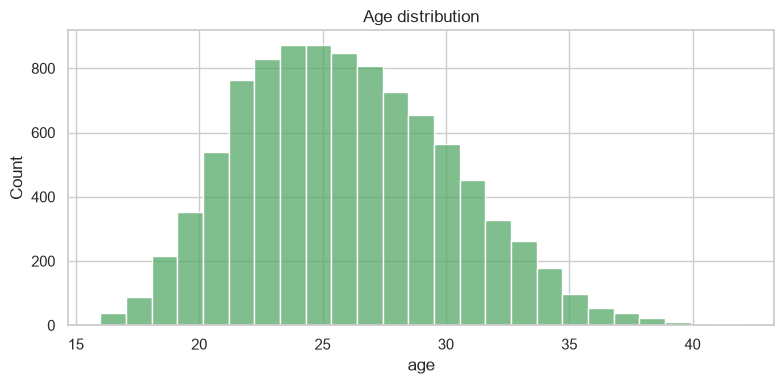

Missing age: 0
Missing nation: 1


In [61]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df_merged['age'].dropna(), bins=25, ax=ax, color='#55A868')
ax.set_title('Age distribution')
plt.tight_layout()
plt.show()

print('Missing age:', df_merged['age'].isna().sum())
print('Missing nation:', df_merged['nation'].isna().sum())


## Positional & League-Quality Weights

Now that the position (Section: Position-Level Comparison) and league (Section: League-Level
Comparison) boxplots have actually been seen, add the two prior-based weight features from
the project plan. Values below are a first-pass prior based on this data's own medians —
adjust if your run shows a different ordering.

In [62]:
POSITION_WEIGHTS = {'FW': 1.00, 'MF': 0.70, 'DF': 0.35, 'GK': 0.05}
df_merged['positional_weight'] = df_merged['primary_pos'].map(POSITION_WEIGHTS).fillna(0.5)

# Sanity check: does the weight ordering match the actual median goals_excl_pk_p90 ordering?
check = df_merged.groupby('primary_pos').agg(
    median_goals_p90=('goals_excl_pk_p90', 'median'),
    weight=('positional_weight', 'first')
).sort_values('median_goals_p90', ascending=False)
check


,median_goals_p90,weight
primary_pos,,
FW,0.31,1.00
MF,0.09,0.70
DF,0.03,0.35
GK,0.00,0.05


In [63]:
LEAGUE_QUALITY_WEIGHTS = {
    'ENG-Premier League': 1.00,
    'ESP-La Liga':        0.92,
    'GER-Bundesliga':     0.85,
    'ITA-Serie A':        0.85,
    'FRA-Ligue 1':        0.75,
}
df_merged['league_quality_weight'] = df_merged['league'].map(LEAGUE_QUALITY_WEIGHTS)

# Sanity check against this data's own league medians
check_league = df_merged.groupby('league').agg(
    median_goals_p90=('goals_excl_pk_p90', 'median'),
    weight=('league_quality_weight', 'first')
).sort_values('median_goals_p90', ascending=False)
check_league


,median_goals_p90,weight
league,,
ENG-Premier League,0.07,1.00
GER-Bundesliga,0.07,0.85
ESP-La Liga,0.06,0.92
FRA-Ligue 1,0.06,0.75
ITA-Serie A,0.06,0.85


If a league or position's median doesn't line up with its assigned weight's rank order,
that's worth revisiting — the weight is meant to reflect competitive strength, and it should
roughly track what the data shows before it's trusted as a model input.

## Re-save Processed Data with Final Features

Overwrite `merged.csv` (and the `attackers.csv` subset) now that `positional_weight` and
`league_quality_weight` are included, so the modelling notebook doesn't have to redo this step.

In [64]:
df_merged.to_csv("../data/processed/merged.csv", index=False)

df_attackers = df_merged[df_merged['pos'].str.contains('FW') | df_merged['pos'].str.contains('MF')].copy()
df_attackers.to_csv("../data/processed/attackers.csv", index=False)

print("Re-saved merged.csv and attackers.csv with positional_weight and league_quality_weight.")


Re-saved merged.csv and attackers.csv with positional_weight and league_quality_weight.


## Modelling Readiness Checklist

- [ ] Multi-team duplicate rows resolved (kept combined OR per-team, not both)
- [ ] `goals_per_shot` / `goals_per_shot_on_target` excluded from model features (leakage)
- [ ] `positional_weight`, `league_quality_weight` sanity-checked against actual medians
- [ ] Target skew decision made (raw `goals_excl_pk_p90` vs. a transform)
- [ ] Train/validation split strategy decided — likely **by season**, not randomly, since the
      season-ahead forecasting stage needs to predict on a held-out future season rather than a
      shuffled sample


## Summary of Findings *(fill in after running)*

- **Coverage:** _N players, after the 900-minute filter_
- **Missingness:** _any columns unreliable enough to drop before modelling?_
- **Target distribution:** _skew — worth a transform before Ridge?_
- **Strongest linear signal:** _which feature correlates most with `goals_excl_pk_p90`?_
- **League effect:** _do league medians justify adding a league-quality weight?_
- **Position effect:** _does attacking output concentrate in FW/MF as expected?_
- **Year-over-year stability:** _correlation strength — how much signal for season-ahead forecasting?_
- **Outliers:** _legitimate elite scorers vs. data-quality issues?_

Next: `02_modeling.ipynb` — Ridge / Random Forest / XGBoost on `data/processed/attackers.csv`
(or `merged.csv` if non-attackers turn out to matter), with SHAP for interpretability.
